<a href="https://colab.research.google.com/github/bavucadoz/PCVK-Ganjil-2026/blob/main/Week5_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Arya Bayu Samodra'
NIM = '244107020162'

N = int(NIM[-3:])
PARAM = {
  'bins' : 2 ** ((N % 4) + 3),
  'clip' : round(1.0 + (N % 5) * 0.5, 1),
  'tile' : (N % 4) + 2,
  'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Arya Bayu Samodra
NIM : 244107020162 | N = 162
bins   : 32
clip   : 2.0
tile   : 4
L      : 2
WAKTU : 2026-09-28 16:06:06 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : d695191c3cc5fdc7


In [15]:
CONTOH = '/content/drive/MyDrive/PCVK/Images' # citra contoh bersama
BASE = '/content/drive/MyDrive/PCVK/Images' # citra KTM milik Anda



---


**E-1 PERCOBAAN HISTOGRAM**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

Membuat histogram citra berdasarkan flowchart di jobsheet. Tahap 1 gunakan citra
contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul;
setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.

<BarContainer object of 256 artists>

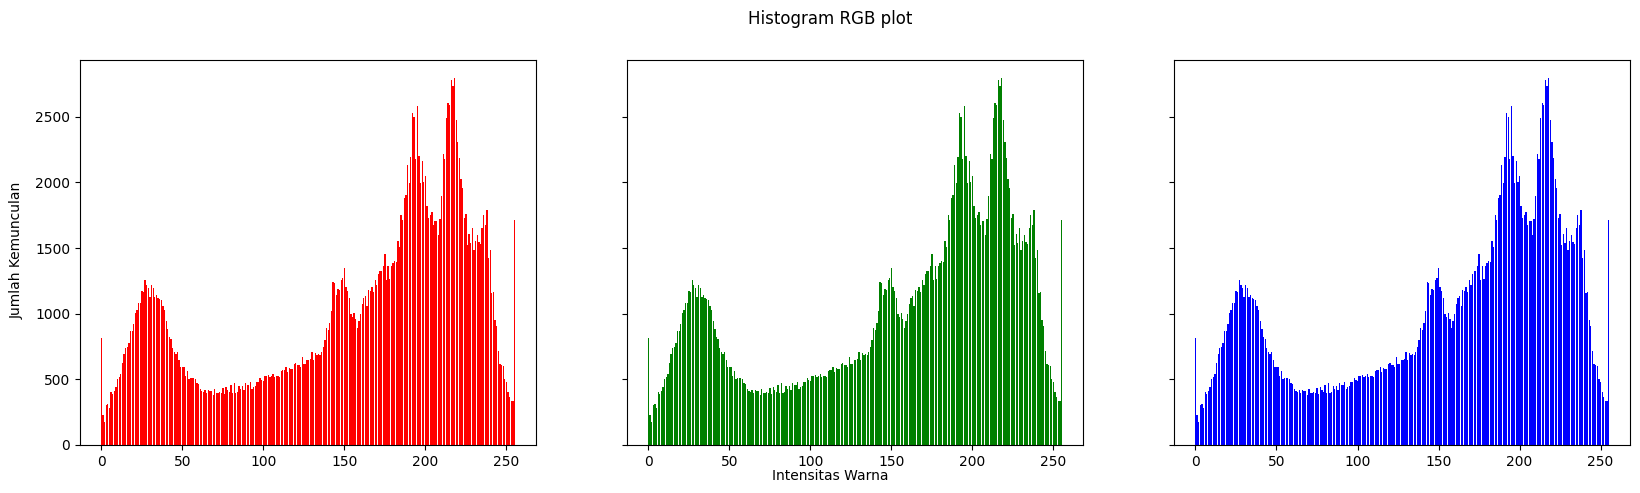

In [5]:
# Membuat Histogram Image (Manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][0]] += 1
    blue[img[y][x][0]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

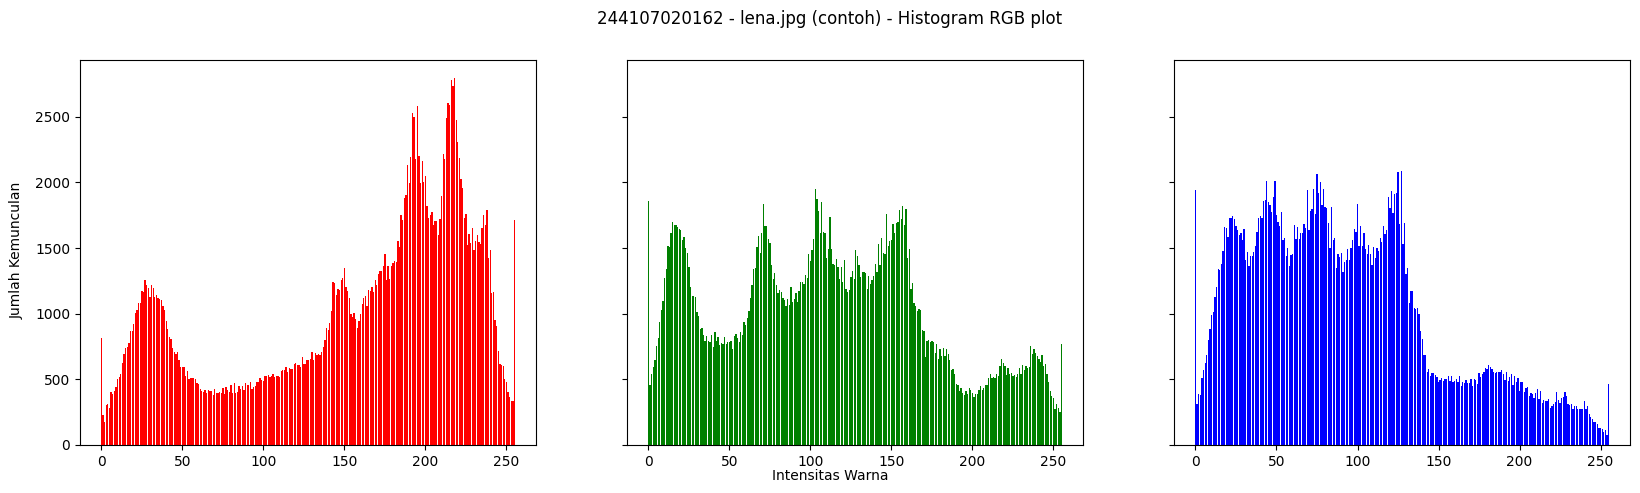

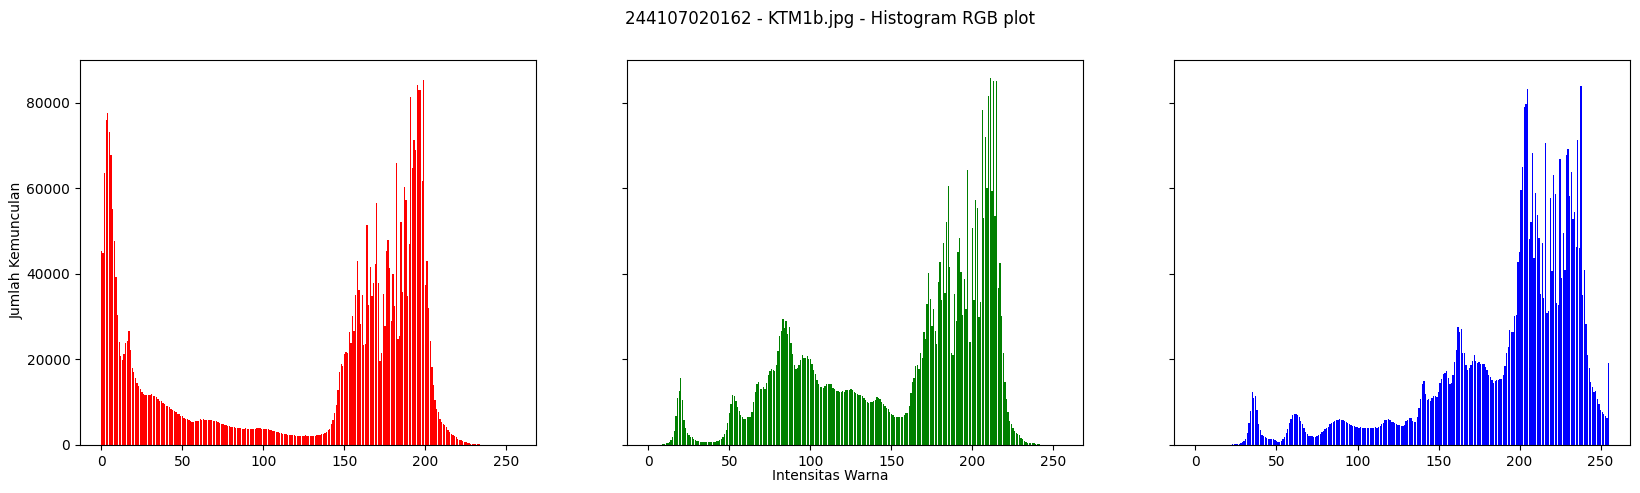

In [16]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h


def plot_rgb_histogram(path, judul_prefix):
    img = cv.imread(path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    names = np.arange(256)
    red   = histogram_manual(img_rgb[:, :, 0])
    green = histogram_manual(img_rgb[:, :, 1])
    blue  = histogram_manual(img_rgb[:, :, 2])

    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(judul_prefix + ' - Histogram RGB plot')
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
    axs[0].bar(names, red, color='red')
    axs[1].bar(names, green, color='green')
    axs[2].bar(names, blue, color='blue')
    plt.show()


# Tahap 1: verifikasi dengan citra contoh
plot_rgb_histogram(CONTOH + '/lena.jpg', NIM + ' - lena.jpg (contoh)')

# Tahap 2: citra pribadi
plot_rgb_histogram(BASE + '/KTM1b.jpg', NIM + ' - KTM1b.jpg')



---


**PERTANYAAN PRAKTIKUM E1**

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [17]:
def bandingkan_histogram(path, label):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    h_manual        = histogram_manual(gray)
    h_numpy, _      = np.histogram(gray, bins=256, range=(0, 256))
    h_cv            = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    d_manual_numpy = np.max(np.abs(h_manual - h_numpy))
    d_manual_cv    = np.max(np.abs(h_manual - h_cv))
    d_numpy_cv     = np.max(np.abs(h_numpy - h_cv))

    print(f'--- {label} ---')
    print('Selisih maks manual vs numpy.histogram :', d_manual_numpy)
    print('Selisih maks manual vs cv.calcHist      :', d_manual_cv)
    print('Selisih maks numpy   vs cv.calcHist      :', d_numpy_cv)
    assert d_manual_numpy == 0 and d_manual_cv == 0 and d_numpy_cv == 0, 'Selisih harus nol!'
    print('LULUS: ketiga metode menghasilkan histogram identik.\n')


# Tahap 1
bandingkan_histogram(CONTOH + '/lena.jpg', NIM + ' - lena.jpg')
# Tahap 2
bandingkan_histogram(BASE + '/KTM1b.jpg', NIM + ' - KTM1b.jpg')

--- 244107020162 - lena.jpg ---
Selisih maks manual vs numpy.histogram : 0
Selisih maks manual vs cv.calcHist      : 0
Selisih maks numpy   vs cv.calcHist      : 0
LULUS: ketiga metode menghasilkan histogram identik.

--- 244107020162 - KTM1b.jpg ---
Selisih maks manual vs numpy.histogram : 0
Selisih maks manual vs cv.calcHist      : 0
Selisih maks numpy   vs cv.calcHist      : 0
LULUS: ketiga metode menghasilkan histogram identik.



2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

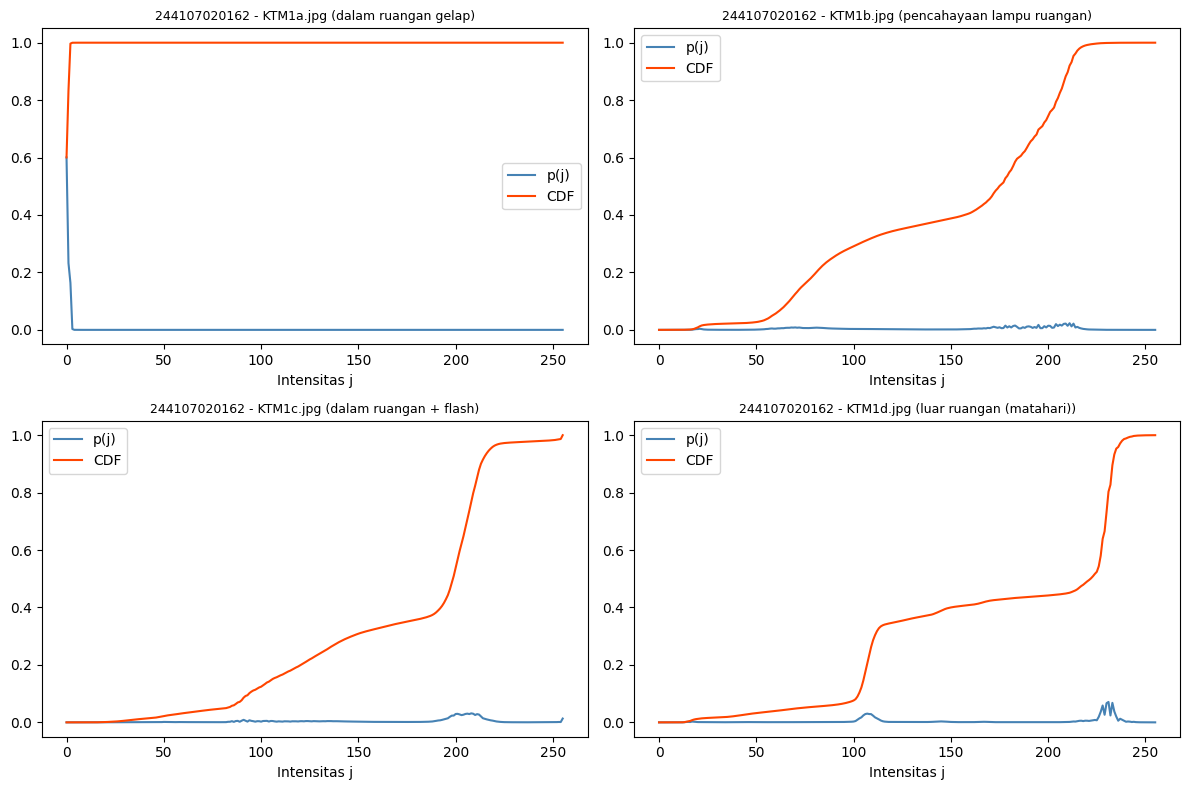

In [18]:
def p_dan_cdf(path):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    return p, cdf


files_ktm  = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
label_ktm  = ['dalam ruangan gelap', 'pencahayaan lampu ruangan', 'dalam ruangan + flash', 'luar ruangan (matahari)']

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()
for ax, fname, label in zip(axs, files_ktm, label_ktm):
    p, cdf = p_dan_cdf(BASE + '/' + fname)
    ax.plot(p,   label='p(j)', color='steelblue')
    ax.plot(cdf, label='CDF',  color='orangered')
    ax.set_title(NIM + ' - ' + fname + ' (' + label + ')', fontsize=9)
    ax.set_xlabel('Intensitas j')
    ax.legend()
fig.tight_layout()
plt.show()

  = Citra Paling Gelap yaitu, KTM1a.jpg - Ruangan Gelap. Kurva CDF naik sangat curam secara mendadak di dekat piksel $j \approx 0$ dan langsung mendatar mencapai nilai 1. Hal ini terjadi karena kondisi akuisisi berada pada lingkungan tanpa pencahayaan, sehingga sensor kamera hanya menangkap intensitas rendah mendekati hitam/0.   
  Citra Paling Terang yaitu KTM1d.jpg - Luar Ruangan. Kurva CDF melandai di rentang intensitas rendah hingga sedang, kemudian mengalami lonjakan tinggi di sekitar intensitas tinggi. Hal ini disebabkan oleh akuisisi di bawah sinar matahari langsung yang melimpah, membuat sebagian besar piksel memiliki nilai kecerahan tinggi.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

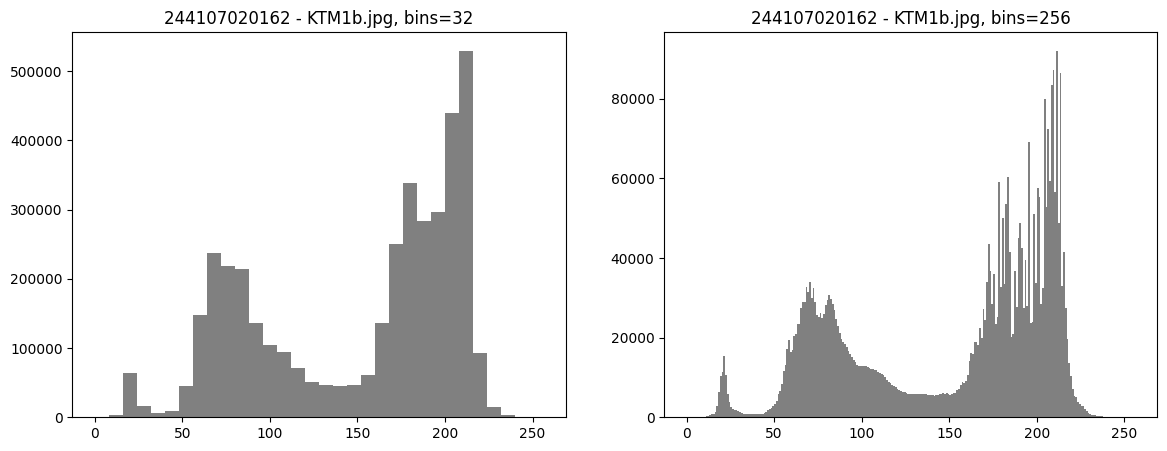

In [19]:
gray_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
h_sedikit, edges_sedikit = np.histogram(gray_ktm1b, bins=PARAM['bins'], range=(0, 256))
h_penuh,   edges_penuh   = np.histogram(gray_ktm1b, bins=256,           range=(0, 256))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].bar(edges_sedikit[:-1], h_sedikit, width=np.diff(edges_sedikit), align='edge', color='gray')
axs[0].set_title(NIM + f" - KTM1b.jpg, bins={PARAM['bins']}")
axs[1].bar(edges_penuh[:-1], h_penuh, width=1, align='edge', color='gray')
axs[1].set_title(NIM + ' - KTM1b.jpg, bins=256')
plt.show()

  = Ketika jumlah bin dikurangi dari 256 menjadi 32, informasi detail tingkat intensitas halus menjadi hilang karena beberapa nilai kecerahan piksel yang berdekatan dikelompokkan ke dalam satu interval rentang yang lebih lebar. Hal ini mengakibatkan hilangnya puncak-puncak tajam distribusi, rincian variasi kontras kecil, serta presisi nilai kecerahan individual piksel, sehingga histogram hanya menyajikan pola kontur umum dari distribusi warna tanpa dapat membedakan perbedaan tingkat abu-abu yang terisolasi secara mendalam.



---

**E-2 PERCOBAAN HISTOGRAM EQUALIZATION**

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

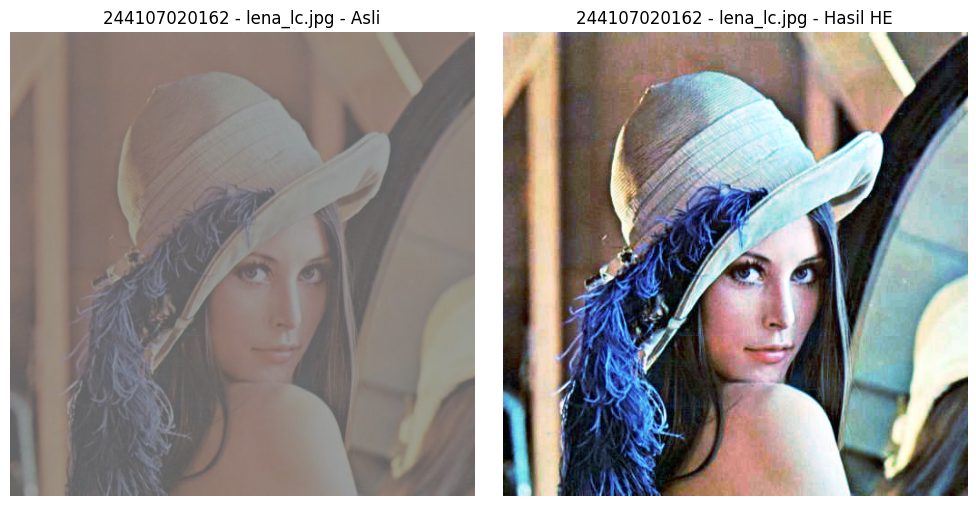

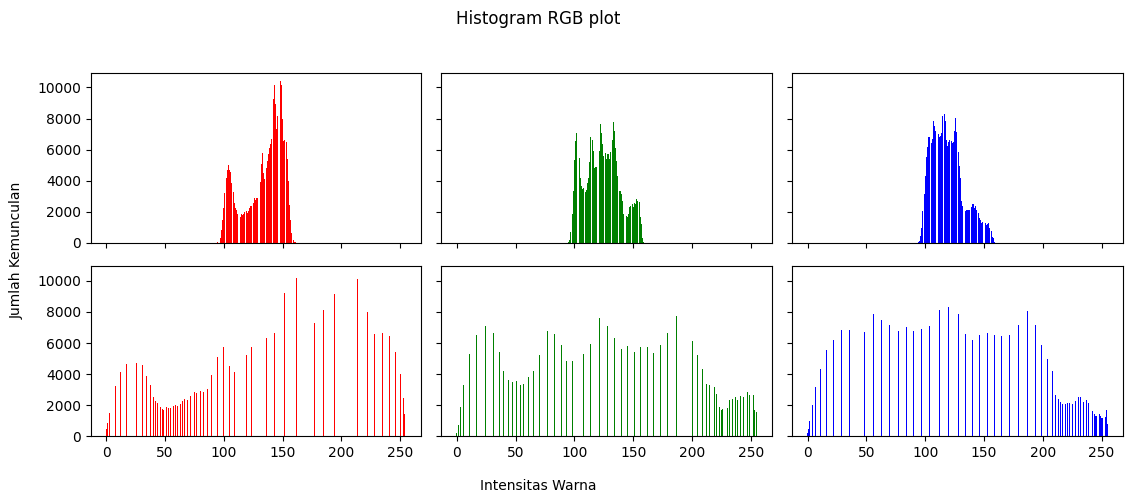

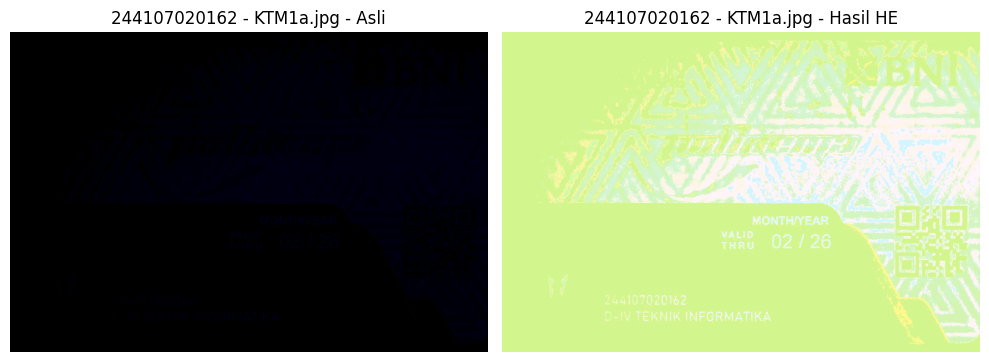

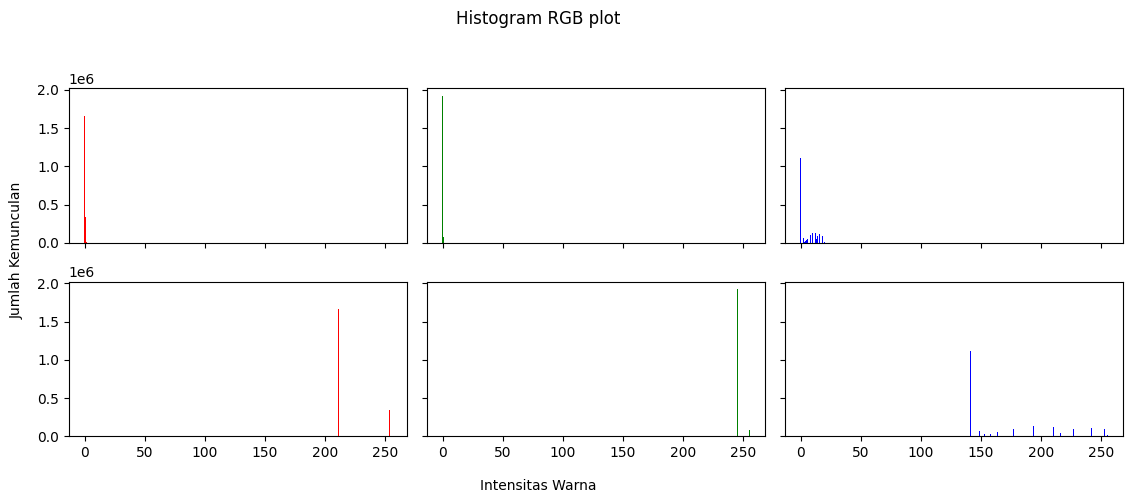

In [26]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def histogram_equalization_manual(channel, L=256):
    h = histogram_manual(channel, L=L)
    cdf = np.cumsum(h) / channel.size
    lut = np.round(cdf * (L - 1)).astype(np.uint8)
    return lut[channel]

def tampilkan_he(path, label):
    img_bgr = cv.imread(path)
    if img_bgr is None:
        print(f"[ERROR] Gambar tidak ditemukan: {path}")
        return None

    img = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Lakukan HE langsung pada tiap saluran RGB
    r_eq = histogram_equalization_manual(img[:, :, 0])
    g_eq = histogram_equalization_manual(img[:, :, 1])
    b_eq = histogram_equalization_manual(img[:, :, 2])
    hasil = np.dstack([r_eq, g_eq, b_eq])

    # Tampilkan Gambar Asli dan Hasil HE
    fig1, axs1 = plt.subplots(1, 2, figsize=(10, 5))
    axs1[0].imshow(img)
    axs1[0].set_title(label + ' - Asli')
    axs1[0].axis('off')

    axs1[1].imshow(hasil)
    axs1[1].set_title(label + ' - Hasil HE')
    axs1[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Tampilkan Histogram RGB (Baris 1: Asli, Baris 2: Hasil HE)
    names = np.arange(256)
    fig2, axs2 = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
    fig2.suptitle('Histogram RGB plot')
    fig2.text(0.06, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig2.text(0.5, 0.02, 'Intensitas Warna', ha='center')

    # Histogram Asli
    axs2[0, 0].bar(names, histogram_manual(img[:, :, 0]), color='red')
    axs2[0, 1].bar(names, histogram_manual(img[:, :, 1]), color='green')
    axs2[0, 2].bar(names, histogram_manual(img[:, :, 2]), color='blue')

    # Histogram Hasil HE
    axs2[1, 0].bar(names, histogram_manual(hasil[:, :, 0]), color='red')
    axs2[1, 1].bar(names, histogram_manual(hasil[:, :, 1]), color='green')
    axs2[1, 2].bar(names, histogram_manual(hasil[:, :, 2]), color='blue')

    plt.tight_layout(rect=[0.07, 0.05, 1, 0.95])
    plt.show()

    return hasil


hasil_lena_lc = tampilkan_he(CONTOH + '/lena_lc.jpg', NIM + ' - lena_lc.jpg')
hasil_ktm1a   = tampilkan_he(BASE + '/KTM1a.jpg', NIM + ' - KTM1a.jpg')

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”, Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut
apabila tidak nol.

In [28]:
def bandingkan_equalizehist(path, label):
    img = cv.imread(path)
    if img is None:
        print(f"[ERROR] Gambar tidak ditemukan pada path: {path}")
        return

    b, g, r = cv.split(img)

    b_m = histogram_equalization_manual(b)
    g_m = histogram_equalization_manual(g)
    r_m = histogram_equalization_manual(r)
    manual = cv.merge([b_m, g_m, r_m])

    # Otomatis cv.equalizeHist
    b_o = cv.equalizeHist(b)
    g_o = cv.equalizeHist(g)
    r_o = cv.equalizeHist(r)
    otomatis = cv.merge([b_o, g_o, r_o])

    selisih = int(np.max(np.abs(manual.astype(np.int16) - otomatis.astype(np.int16))))
    print(f'{label}: selisih maksimum manual vs cv.equalizeHist = {selisih}')
    return selisih


bandingkan_equalizehist(CONTOH + '/lena_lc.jpg', NIM + ' - lena_lc.jpg')
bandingkan_equalizehist(BASE + '/KTM1a.jpg', NIM + ' - KTM1a.jpg')

244107020162 - lena_lc.jpg: selisih maksimum manual vs cv.equalizeHist = 0
244107020162 - KTM1a.jpg: selisih maksimum manual vs cv.equalizeHist = 245


245

  = Hasil perbandingan menunjukkan selisih maksimum bernilai 0 pada lena_lc.jpg karena distribusi pikselnya tersebar tanpa akumulasi ekstrem di nilai awal, sehingga rumus manual dan OpenCV menghasilkan nilai pemetaan yang identik. Sebaliknya, terdapat selisih sebesar 245 pada KTM1a.jpg karena citra tersebut sangat gelap dengan mayoritas piksel bernilai 0, yang dimana pada formulasi manual tanpa pengorangan $CDF_{min}$, nilai $CDF[0]$ langsung terakumulasi mendekati $1{,}0$ yang memetakan piksel hitam (0) menjadi hampir putih ($\approx 255$), sedangkan cv.equalizeHist memperhitungkan $CDF_{min}$ sehingga area gelap tetap berada pada intensitas rendah (mendekati 0). Perbedaan mendasar dalam penanganan piksel $0$ inilah yang memicu selisih intensitas yang sangat besar hingga 245 di antara keduanya.

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

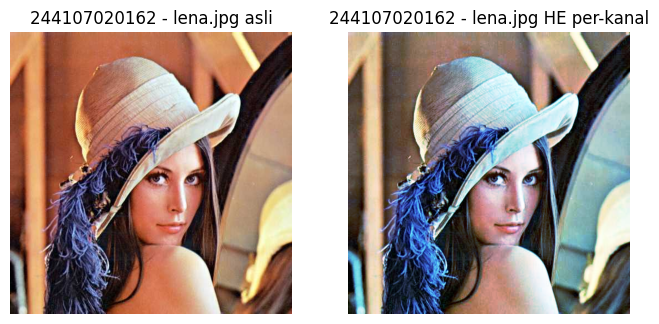

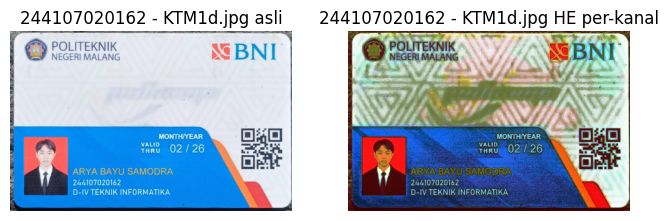

In [29]:
berkas = CONTOH + '/lena.jpg'
bgr = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb_lena = cv.merge(kanal)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));        plt.title(NIM + ' - lena.jpg asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_rgb_lena, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - lena.jpg HE per-kanal'); plt.axis('off')
plt.show()

# tahap 2
berkas2 = BASE + '/KTM1d.jpg'
bgr2 = cv.imread(berkas2)
kanal2 = list(cv.split(bgr2))
for i in range(3):
    kanal2[i] = cv.equalizeHist(kanal2[i])
he_rgb_ktm1d = cv.merge(kanal2)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr2, cv.COLOR_BGR2RGB));           plt.title(NIM + ' - KTM1d.jpg asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_rgb_ktm1d, cv.COLOR_BGR2RGB));   plt.title(NIM + ' - KTM1d.jpg HE per-kanal'); plt.axis('off')
plt.show()

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna
YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal
L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg)

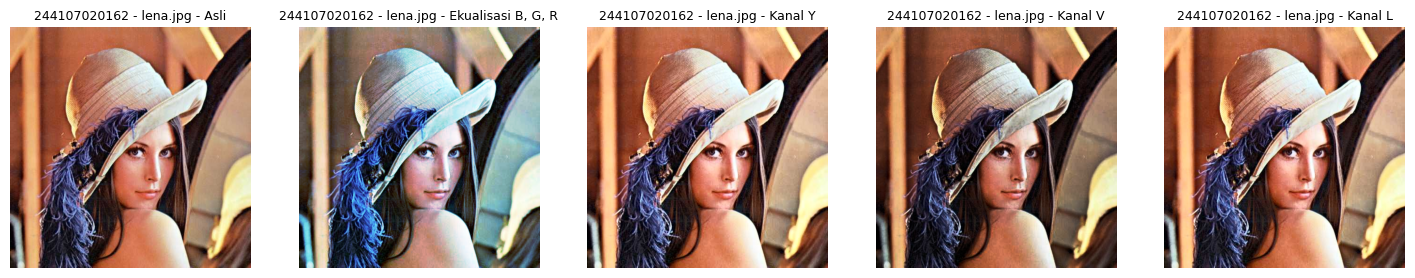

--- 244107020162 - lena.jpg ---
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7



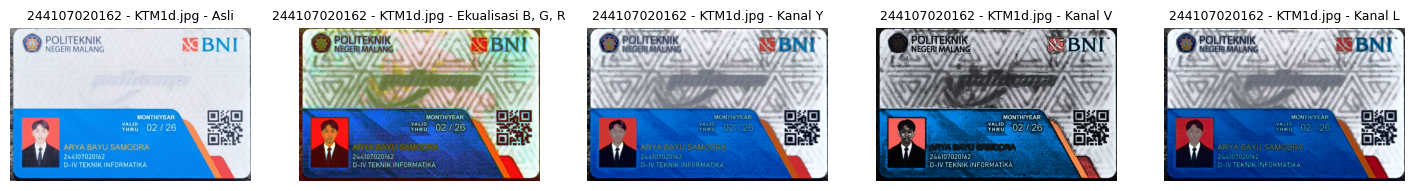

--- 244107020162 - KTM1d.jpg ---
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            176.2
Ekualisasi B, G, R                80.31            129.8
Kanal Y                            2.81            135.2
Kanal V                            2.09            106.6
Kanal L                            5.71            124.9



In [30]:
def eq_warna_lengkap(path, prefix):
    bgr = cv.imread(path)

    # cara 1: tiap kanal diekualisasi sendiri-sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # cara 2: hanya kanal terang yang diekualisasi
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # varian setara pada ruang warna lain
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(prefix + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.show()

    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d)      # Hue melingkar 0-179
        return d.mean()

    print(f'--- {prefix} ---')
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    hasil_tabel = []
    for t, c in zip(judul, citra):
        geser = geser_hue(bgr, c) * 2
        terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        print('%-22s %16.2f %16.1f' % (t, geser, terang))
        hasil_tabel.append((t, geser, terang))
    print()
    return citra, judul, hasil_tabel


# Tahap 1: verifikasi
_ = eq_warna_lengkap(CONTOH + '/lena.jpg', NIM + ' - lena.jpg')
# Tahap 2: citra sendiri
citra_ktm1d, judul_ktm1d, tabel_ktm1d = eq_warna_lengkap(BASE + '/KTM1d.jpg', NIM + ' - KTM1d.jpg')

Tabel rata-rata pergeseran Hue dan rerata kecerahan KTM1d

| Cara ekualisasi          | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---------------------------|:-----------------------------------:|:--------------------------:|-----------------------------|
| Citra asli                | 0                                    | 176.2                           | Kecerahan dan warna alami, detail foto diri dan teks terlihat jelas.                            |
| Ekualisasi kanal B, G, R  |  80.31           | 129.8                     | Distorsi warna sangat parah, muncul warna kemerahan dan kehijauan tidak alami.                      |
| Kanal Y (YCrCb)            | 2.81                              | 135.2                     | Kontras meningkat, motif latar belakang dan teks lebih jelas, namun warna terlihat keruh.                      |
| Kanal V (HSV)               | 2.09                              | 106.6                    | Citra menjadi terlalu gelap secara keseluruhan, kontras latar sangat tinggi dan foto diri terlalu gelap                      |
| Kanal L (LAB)                | 5.71                              | 124.9                     | Kontras warna yang sedikit lebih tinggi dibanding Kanal Y                    |


  1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?
    = *Cara yang menghasilkan pergeseran Hue paling besar adalah Ekualisasi kanal B, G, R secara terpisah dengan pergeseran nilai Hue sebesar 80.31 derajat.*

  2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.
    = *Ketika ekualisasi dilakukan hanya pada kanal terang (seperti Y, V, atau L), terjadi perubahan nilai kecerahan pada tiap piksel secara individual. Saat citra dikembalikan ke ruang warna BGR, konversi melibatkan perhitungan matematis floating-point yang dilanjutkan dengan proses pembulatan (rounding) dan pemotongan (clipping) ke rentang integer uint8 (0–255). Perubahan kecil pada proporsi rasio antar komponen B, G, dan R akibat pembulatan dan clipping tersebut sedikit mengubah rasio warna, sehingga memicu pergeseran Hue yang bernilai kecil (tidak persis nol).*

  3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.
    = *Kanal Y, karena memiliki pergeseran Hue yang tergolong kecil dengan rerata kecerahan yang paling seimbang. Hal ini juga terlihat pada bagian foto wajah dan latar belakang watermark KTM. Pada Kanal V, foto wajah menjadi sangat gelap dan kehilangan detail kecerahan. Sedangkan, pada Kanal Y raut wajah tetap terlihat jelas, tekstur motif latar belakang tajam, meskipun memang agak terlihat keruh.*

  4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.

--- 244107020162: CLAHE clip=2.0, tile=4 vs equalizeHist biasa (kanal Y) ---
CLAHE       : geser Hue = 0.24 derajat, rerata terang = 169.4
equalizeHist: geser Hue = 2.81 derajat, rerata terang = 135.2


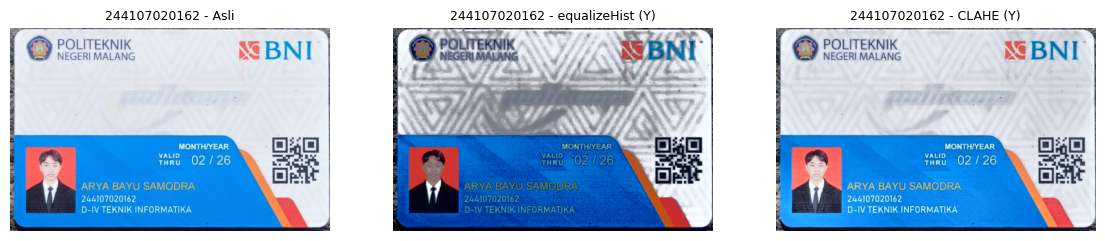

In [31]:
def clahe_kanal_y(path, prefix, clip, tile):
    bgr = cv.imread(path)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)

    clahe = cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    y_clahe = clahe.apply(y)
    hasil_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

    y_eq = cv.equalizeHist(y)
    hasil_eq = cv.cvtColor(cv.merge([y_eq, cr, cb]), cv.COLOR_YCrCb2BGR)

    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d)
        return d.mean()

    print(f'--- {prefix}: CLAHE clip={clip}, tile={tile} vs equalizeHist biasa (kanal Y) ---')
    print('CLAHE       : geser Hue = %.2f derajat, rerata terang = %.1f' %
          (geser_hue(bgr, hasil_clahe) * 2, cv.cvtColor(hasil_clahe, cv.COLOR_BGR2GRAY).mean()))
    print('equalizeHist: geser Hue = %.2f derajat, rerata terang = %.1f' %
          (geser_hue(bgr, hasil_eq) * 2, cv.cvtColor(hasil_eq, cv.COLOR_BGR2GRAY).mean()))

    fig, axs = plt.subplots(1, 3, figsize=(14, 5))
    for ax, img, t in zip(axs, [bgr, hasil_eq, hasil_clahe], ['Asli', 'equalizeHist (Y)', 'CLAHE (Y)']):
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        ax.set_title(prefix + ' - ' + t, fontsize=9)
        ax.axis('off')
    plt.show()


clahe_kanal_y(BASE + '/KTM1d.jpg', NIM, PARAM['clip'], PARAM['tile'])



---

**PERTANYAAN PRAKTIKUM E2**

1. Ekualisasi global pada citra KTM Anda



    *  Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
    grayscale.
    *  Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
    * Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
    PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
    layak dipakai untuk menilai keterbacaan sebuah citra.


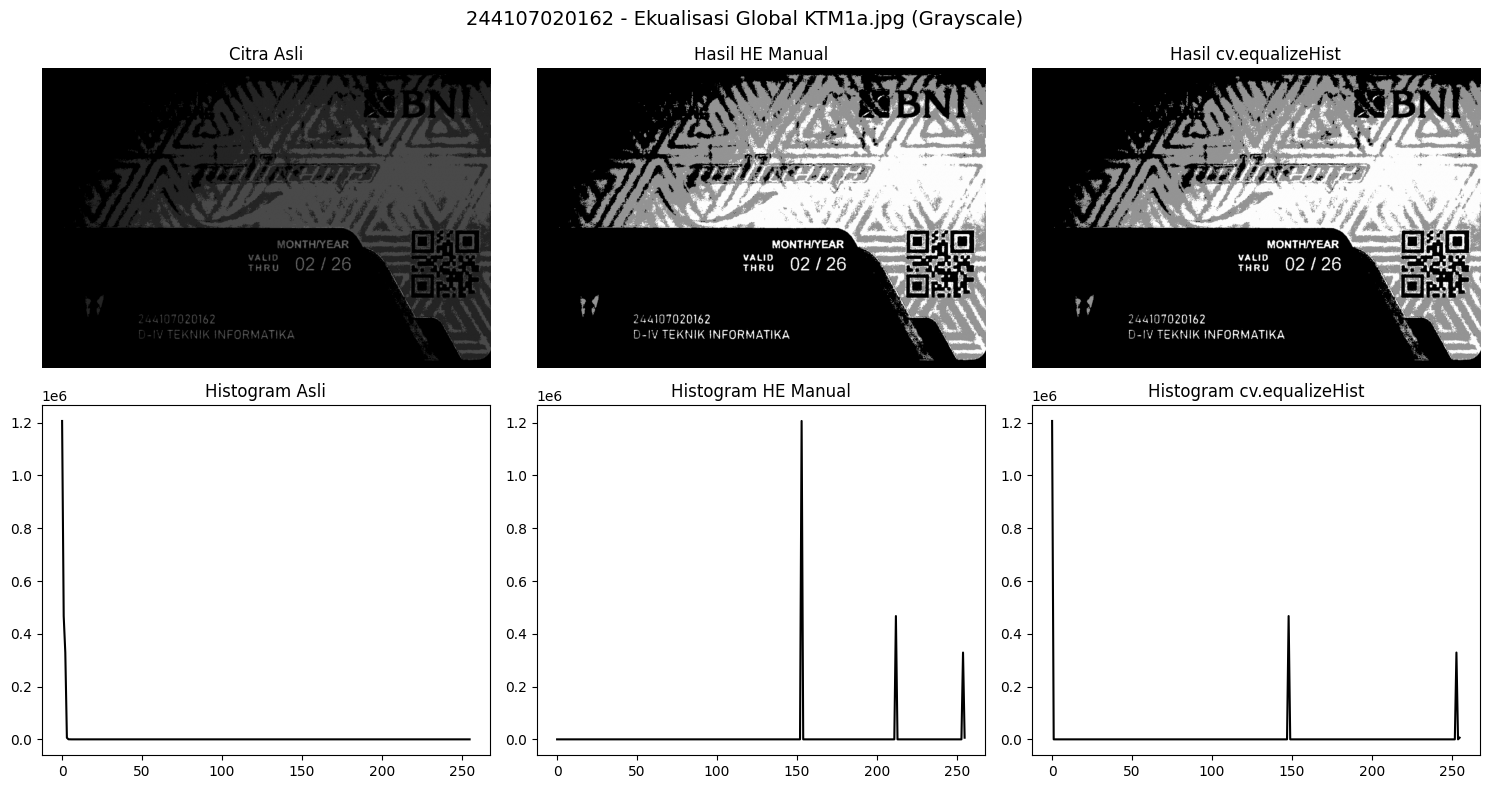

PSNR Citra Asli vs HE Manual : 2.69 dB
PSNR Citra Asli vs cv2.equalizeHist : 6.22 dB


In [34]:
def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

gray_a = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

if gray_a is None:
    print("[ERROR] Citra KTM1a.jpg tidak ditemukan.")
else:
    hasil_manual = histogram_equalization_manual(gray_a)
    hasil_cv2    = cv.equalizeHist(gray_a)

    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(NIM + ' - Ekualisasi Global KTM1a.jpg (Grayscale)', fontsize=14)

    # Baris 1: Tampilan Citra
    axs[0, 0].imshow(gray_a, cmap='gray')
    axs[0, 0].set_title('Citra Asli')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(hasil_manual, cmap='gray')
    axs[0, 1].set_title('Hasil HE Manual')
    axs[0, 1].axis('off')

    axs[0, 2].imshow(hasil_cv2, cmap='gray')
    axs[0, 2].set_title('Hasil cv.equalizeHist')
    axs[0, 2].axis('off')

    # Baris 2: Histogram
    axs[1, 0].plot(histogram_manual(gray_a), color='black')
    axs[1, 0].set_title('Histogram Asli')

    axs[1, 1].plot(histogram_manual(hasil_manual), color='black')
    axs[1, 1].set_title('Histogram HE Manual')

    axs[1, 2].plot(histogram_manual(hasil_cv2), color='black')
    axs[1, 2].set_title('Histogram cv.equalizeHist')

    plt.tight_layout()
    plt.show()

    # Hitung Nilai PSNR
    psnr_manual = psnr(gray_a, hasil_manual)
    psnr_cv2    = psnr(gray_a, hasil_cv2)

    print(f"PSNR Citra Asli vs HE Manual : {psnr_manual:.2f} dB")
    print(f"PSNR Citra Asli vs cv2.equalizeHist : {psnr_cv2:.2f} dB")

= Penerapan ekualisasi histogram global pada citra KTM1a.jpg versi grayscale berhasil meningkatkan kontras dan keterbacaan detail kartu secara signifikan dengan merenggangkan distribusi piksel dari area serba gelap ke rentang intensitas yang lebih terang. Meskipun tampilan visual citra menjadi jauh lebih jelas, nilai PSNR yang dihasilkan bernilai sangat rendah ($2,69\text{ dB}$ untuk manual dan $6,22\text{ dB}$ untuk OpenCV) karena metrik berbasis MSE ini mengukur besarnya perubahan nilai piksel secara matematis dan menganggap pergeseran drastis intensitas tersebut sebagai bentuk distorsi sinyal. Dengan demikian, PSNR terbukti tidak layak digunakan untuk menilai tingkat keterbacaan sebuah citra karena metrik tersebut hanya mengukur kesetiaan sinyal terhadap citra acuan asli, bukan kualitas persepsi visual manusia.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda


    *   Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
    tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
    global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
    *   Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
    tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
    noise-nya mulai menonjol ketika clipLimit dinaikkan.



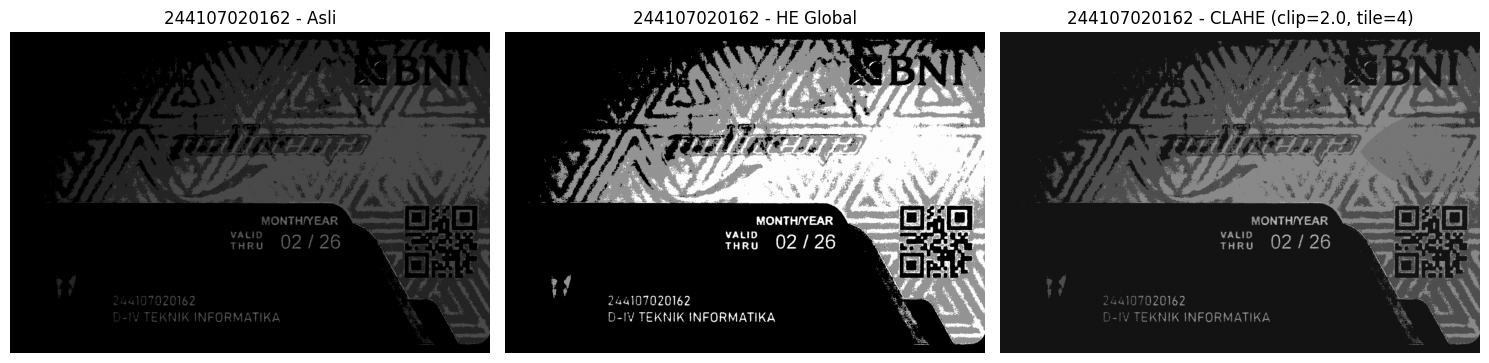

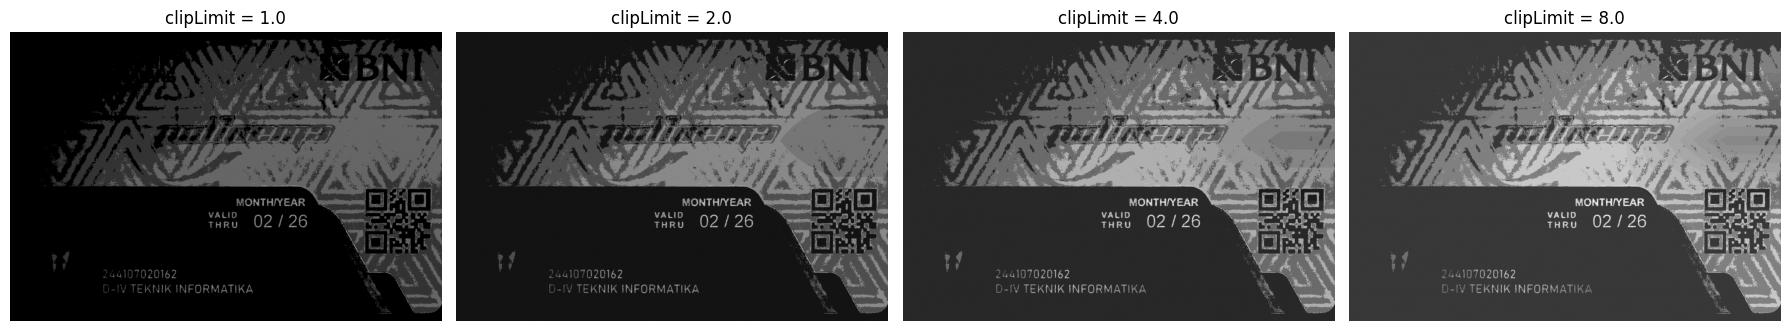

In [35]:
gray_a = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

hasil_global = cv.equalizeHist(gray_a)

clahe_default = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_def = clahe_default.apply(gray_a)

# Visualisasi Perbandingan
fig1, axs1 = plt.subplots(1, 3, figsize=(15, 5))
axs1[0].imshow(gray_a, cmap='gray');          axs1[0].set_title(f"{NIM} - Asli");          axs1[0].axis('off')
axs1[1].imshow(hasil_global, cmap='gray');     axs1[1].set_title(f"{NIM} - HE Global");     axs1[1].axis('off')
axs1[2].imshow(hasil_clahe_def, cmap='gray'); axs1[2].set_title(f"{NIM} - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})"); axs1[2].axis('off')
plt.tight_layout()
plt.show()

# Uji Coba Variasi clipLimit
clip_variations = [1.0, PARAM['clip'], 4.0, 8.0]

fig2, axs2 = plt.subplots(1, len(clip_variations), figsize=(18, 5))

for idx, clip_val in enumerate(clip_variations):
    clahe_var = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_var = clahe_var.apply(gray_a)

    axs2[idx].imshow(hasil_var, cmap='gray')
    axs2[idx].set_title(f"clipLimit = {clip_val}")
    axs2[idx].axis('off')

plt.tight_layout()
plt.show()

= Teks NIM dan nama pada kartu jauh lebih jelas dan mudah dibaca pada hasil CLAHE dibandingkan ekualisasi global karena CLAHE meningkatkan kontras secara lokal tanpa menimbulkan efek over-exposure ekstrem yang menghapus detail area di sekitarnya. Di antara variasi clipLimit, nilai terbaik adalah clipLimit = 2.0 karena memberikan tingkat keterbacaan tulisan paling optimal dengan tampilan visual yang seimbang. Sebaliknya, ketika clipLimit dinaikkan ke 4.0 hingga 8.0, noise atau derau berbentuk bintik-bintik granul mulai menonjol jelas di area latar belakang gelap yang homogen serta di sekitar motif watermark kartu akibat tingginya batas penguatan kontras lokal.



---

**E-3 TUGAS PRAKTIKUM DITHERING**

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul jobsheet, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

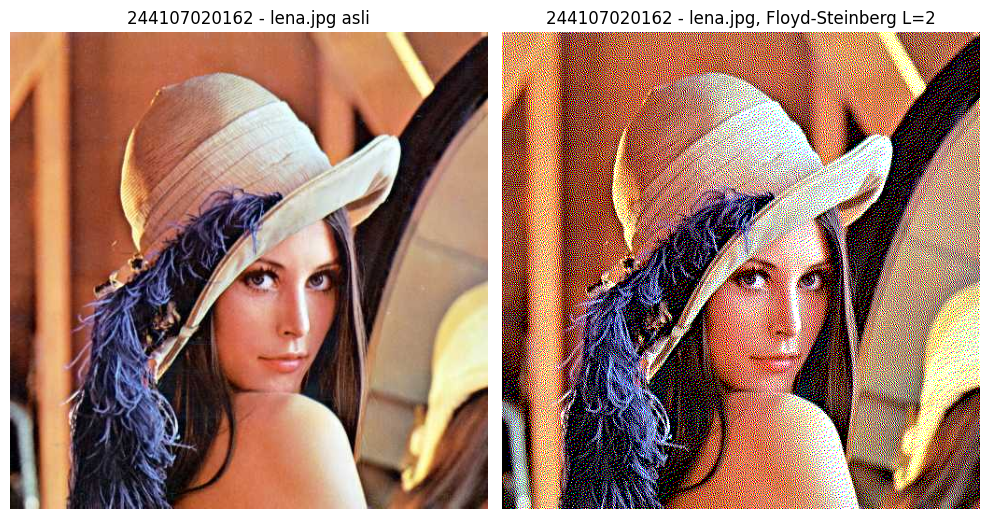

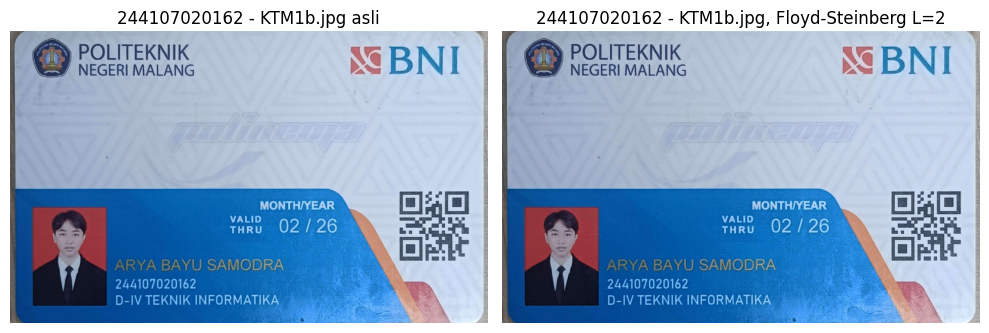

In [38]:
def floyd_steinberg(gray, L):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step     # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                  img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:        img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                  img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:    img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


def floyd_steinberg_warna(rgb, L=2):
    # Proses dithering secara terpisah pada channel R, G, dan B
    r_dither = floyd_steinberg(rgb[:, :, 0], L=L)
    g_dither = floyd_steinberg(rgb[:, :, 1], L=L)
    b_dither = floyd_steinberg(rgb[:, :, 2], L=L)
    return np.dstack([r_dither, g_dither, b_dither])


def tampilkan_dithering(path, label, L):
    img_bgr = cv.imread(path)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    hasil_rgb = floyd_steinberg_warna(img_rgb, L=L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 6))
    axs[0].imshow(img_rgb)
    axs[0].set_title(label + ' asli')
    axs[0].axis('off')

    axs[1].imshow(hasil_rgb)
    axs[1].set_title(label + f', Floyd-Steinberg L={L}')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()
    return img_rgb, hasil_rgb


# Tahap 1: Verifikasi citra contoh
_ = tampilkan_dithering(CONTOH + '/lena.jpg', NIM + ' - lena.jpg', L=2)

# Tahap 2: Citra pribadi KTM
_ = tampilkan_dithering(BASE + '/KTM1b.jpg', NIM + ' - KTM1b.jpg', L=PARAM['L'])

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

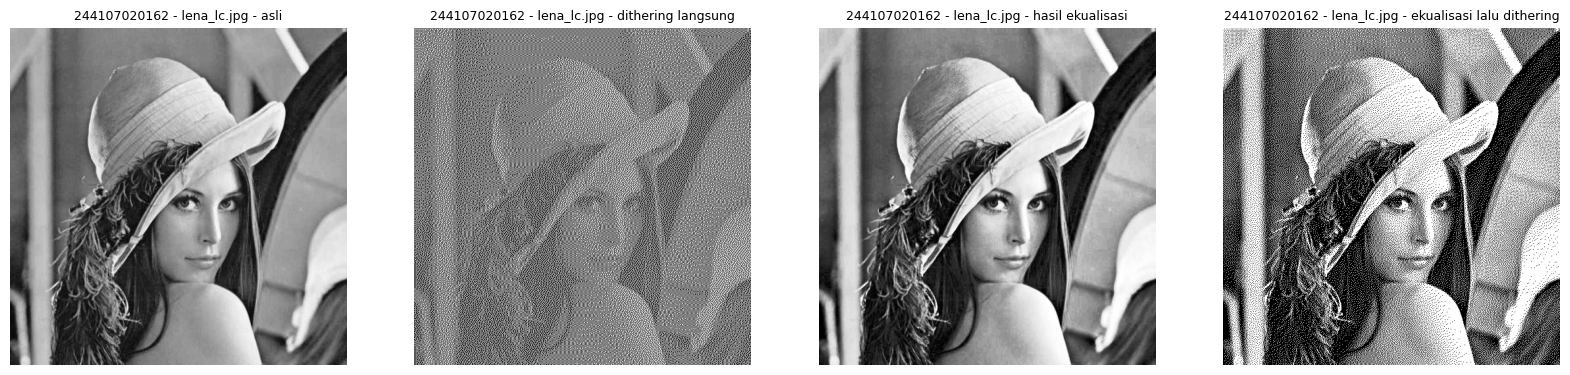

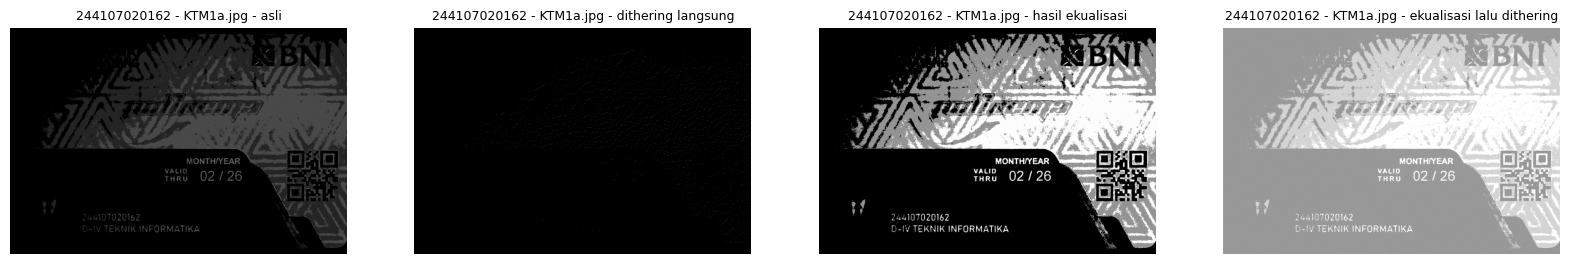

In [39]:
def bandingkan_pipeline_dithering(path, label, L):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    dithering_langsung = floyd_steinberg(gray, L=L)
    hasil_eq = histogram_equalization_manual(gray)
    eq_lalu_dithering = floyd_steinberg(hasil_eq, L=L)

    judul = ['asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']
    citra = [gray, dithering_langsung, hasil_eq, eq_lalu_dithering]

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for ax, c, t in zip(axs, citra, judul):
        ax.imshow(c, cmap='gray')
        ax.set_title(label + ' - ' + t, fontsize=9)
        ax.axis('off')
    plt.show()
    return citra


# Tahap 1: verifikasi (harus sama dengan gambar contoh pada modul)
_ = bandingkan_pipeline_dithering(CONTOH + '/lena_lc.jpg', NIM + ' - lena_lc.jpg', L=2)
# Tahap 2
_ = bandingkan_pipeline_dithering(BASE + '/KTM1a.jpg', NIM + ' - KTM1a.jpg', L=PARAM['L'])

= Urutan ekualisasi lalu dithering menghasilkan teks pada KTM1a.jpg yang jauh lebih mudah dan jelas terbaca dibandingkan dithering secara langsung. Pada citra KTM1a.jpg yang awalnya gelap, proses dithering langsung membuat hampir seluruh piksel terkuantisasi menjadi warna hitam sehingga detail teks menyatu dengan latar belakang dan tidak tampak sama sekali.